In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("student_performance.csv")

print("="*50)
print("DATASET PREVIEW")
print("="*50)
print(df.head())

DATASET PREVIEW
   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad           

In [2]:
print("\nDATASET SHAPE")
print(df.shape)

print("\nDATA TYPES")
print(df.dtypes)

print("\nNULL VALUE ANALYSIS")
print(df.isnull().sum())

print("\nMISSING VALUE PERCENTAGE")
print((df.isnull().sum()/len(df))*100)


DATASET SHAPE
(30, 13)

DATA TYPES
student_id                int64
name                     object
age                       int64
gender                   object
department               object
semester                  int64
math_score                int64
science_score             int64
english_score             int64
programming_score         int64
attendance_percentage     int64
city                     object
admission_year            int64
dtype: object

NULL VALUE ANALYSIS
student_id               0
name                     0
age                      0
gender                   0
department               0
semester                 0
math_score               0
science_score            0
english_score            0
programming_score        0
attendance_percentage    0
city                     0
admission_year           0
dtype: int64

MISSING VALUE PERCENTAGE
student_id               0.0
name                     0.0
age                      0.0
gender                   0.0
departm

In [3]:
df["average_score"] = (
    df["math_score"] +
    df["science_score"] +
    df["english_score"] +
    df["programming_score"]
) / 4

In [4]:
print("\nDepartment-wise Average Score & Attendance")

dept_analysis = df.groupby("department").agg({
    "average_score":"mean",
    "attendance_percentage":"mean"
}).round(2)

display(dept_analysis)





Department-wise Average Score & Attendance


,average_score,attendance_percentage
department,,
Civil,58.95,74.60
Computer Science,85.04,90.69
Electronics,69.38,80.33
Mechanical,66.83,83.50


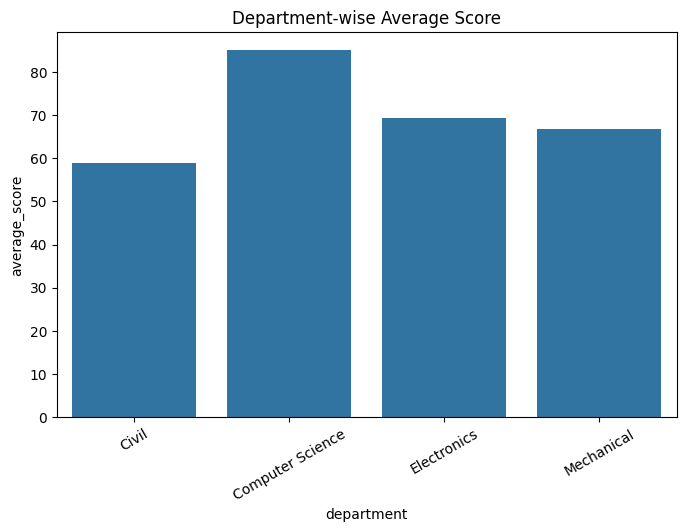

In [5]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=dept_analysis.reset_index(),
    x="department",
    y="average_score"
)
plt.title("Department-wise Average Score")
plt.xticks(rotation=30)
plt.show()

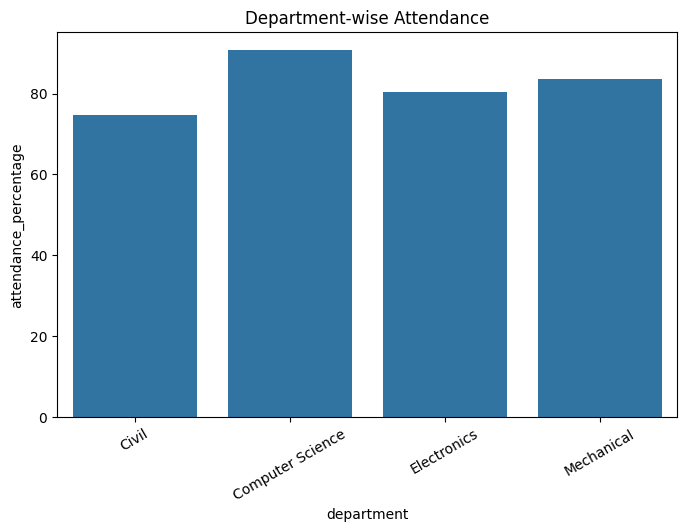

In [6]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=dept_analysis.reset_index(),
    x="department",
    y="attendance_percentage"
)
plt.title("Department-wise Attendance")
plt.xticks(rotation=30)
plt.show()


In [7]:
print("\nTop Performers (Average Score >= 85)")

top_performers = df[df["average_score"] >= 85]

display(
    top_performers[
        ["name","department","average_score"]
    ].sort_values(
        by="average_score",
        ascending=False
    )
)


Top Performers (Average Score >= 85)


,name,department,average_score
9,Ananya Das,Computer Science,92.75
21,Tanvi Mehta,Computer Science,91.75
29,Akanksha Yadav,Computer Science,91.25
4,Arjun Nair,Computer Science,89.00
7,Divya Singh,Computer Science,89.00
17,Swati Kulkarni,Computer Science,88.50


In [8]:
gender_analysis = df.groupby("gender").agg({
    "average_score":"mean",
    "attendance_percentage":"mean"
}).round(2)

print("\nGender-wise Analysis")
display(gender_analysis)


Gender-wise Analysis


,average_score,attendance_percentage
gender,,
Female,77.67,88.53
Male,70.17,80.47


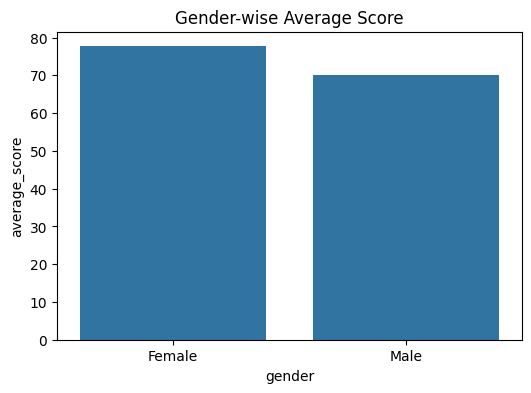

In [9]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=gender_analysis.reset_index(),
    x="gender",
    y="average_score"
)
plt.title("Gender-wise Average Score")
plt.show()

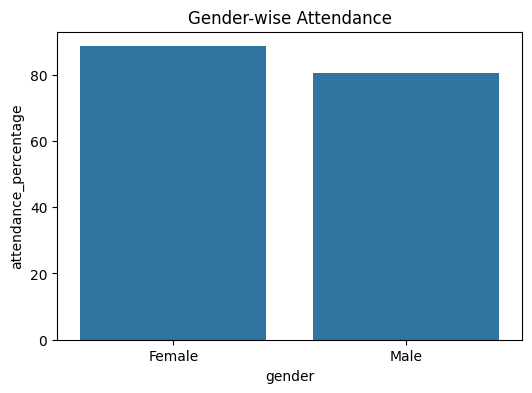

In [10]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=gender_analysis.reset_index(),
    x="gender",
    y="attendance_percentage"
)
plt.title("Gender-wise Attendance")
plt.show()

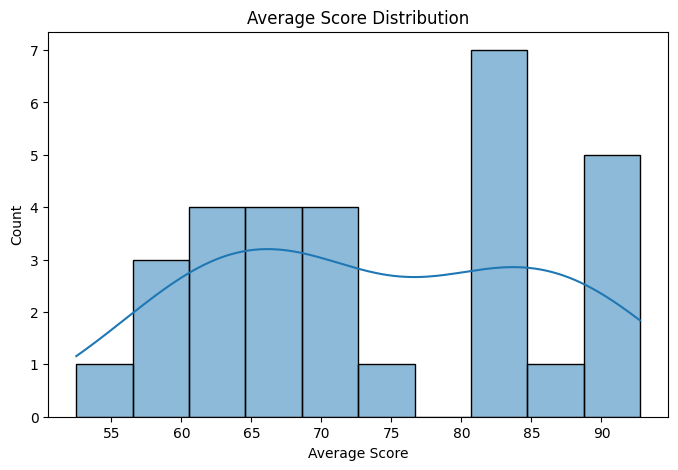

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["average_score"],
    bins=10,
    kde=True
)

plt.title("Average Score Distribution")
plt.xlabel("Average Score")
plt.show()

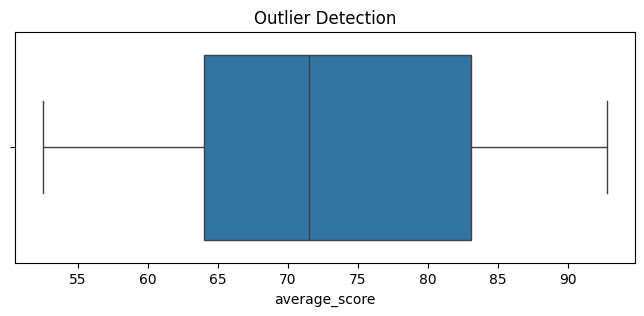


Outlier Students:


,name,department,average_score


In [12]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df["average_score"])
plt.title("Outlier Detection")
plt.show()

# IQR Method

Q1 = df["average_score"].quantile(0.25)
Q3 = df["average_score"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["average_score"] < lower) |
    (df["average_score"] > upper)
]

print("\nOutlier Students:")
display(outliers[["name","department","average_score"]])


In [13]:
print("\nTop 5 Students Overall")

top5 = df.sort_values(
    by="average_score",
    ascending=False
).head(5)

display(
    top5[
        ["name","department","average_score"]
    ]
)




Top 5 Students Overall


,name,department,average_score
9,Ananya Das,Computer Science,92.75
21,Tanvi Mehta,Computer Science,91.75
29,Akanksha Yadav,Computer Science,91.25
4,Arjun Nair,Computer Science,89.00
7,Divya Singh,Computer Science,89.00


In [14]:
print("="*50)
print("DASHBOARD SUMMARY")
print("="*50)

print("Total Students:", len(df))
print("Departments:", df["department"].nunique())
print("Average Score:", round(df["average_score"].mean(),2))
print("Average Attendance:", round(df["attendance_percentage"].mean(),2))
print("Top Performers:", len(top_performers))
print("Outliers:", len(outliers))

DASHBOARD SUMMARY
Total Students: 30
Departments: 4
Average Score: 73.92
Average Attendance: 84.5
Top Performers: 6
Outliers: 0
